# **15 - Synthetic Control**

## 알 수 없는 것을 알아내는 놀라운 수학 트릭

### 1.1 DID가 집계 데이터에서 겪는 문제

DID(Difference-in-Differences) 챕터에서는 Porto Alegre와 Florianópolis 두 도시의 고객 데이터를 다뤘습니다. 개입 전후 두 시점에 걸쳐 있었고, 처치 효과와 표준오차를 회귀분석으로 추정할 수 있었어요.

그런데 만약 개인별 데이터가 아니라, **도시 단위로 이미 집계된 평균값만** 있다면 어떨까요? 예를 들어 개입 전후 두 도시의 평균 예금만 있는 상황이에요.

|city|before|after|
|--|--|--|
|FL|171.64|206.16|
|POA|46.01|87.06|

여전히 DID 추정량은 계산할 수 있습니다.

$$
(E[Y(1)|D=1] - E[Y(1)|D=0]) - (E[Y(0)|D=1] - E[Y(0)|D=0]) = (87.06 - 206.16) - (46.01 - 171.64) = 6.53
$$

문제는 여기서 **샘플 크기가 딱 4개**(도시 2개 × 시점 2개)라는 점이에요. 그런데 DID 모델이 추정해야 하는 매개변수(도시 효과, 시간 효과, 처치 효과 등) 개수도 이와 비슷한 수준입니다. \
**추정할 정보(매개변수)의 개수가 갖고 있는 데이터 개수와 비슷하거나 더 많으면, 표준오차를 신뢰성 있게 계산할 방법이 없어요.** 그래서 이 값이 통계적으로 유의미한지 판단할 수가 없습니다.

또 다른 문제는 **대조군 선택의 임의성**입니다. Florianópolis가 Porto Alegre와 정말 비슷한 도시인지 확신할 수 없어요. Florianópolis는 아름다운 해변과 여유로운 분위기로 유명하고, Porto Alegre는 바베큐와 초원으로 알려진, 서로 다른 특징을 가진 도시입니다.\
"적절한 대조군을 쓰고 있는가"라는 질문에 명확히 답하기 어려운 거예요.

### Synthetic Control 아이디어

이 두 문제를 해결하기 위해 [**"최근 몇 년간 정책 평가 문헌에서 가장 중요한 혁신"**](https://www.aeaweb.org/articles?id=10.1257/jep.31.2.3)으로 불리는 **Synthetic Control** 방법을 사용합니다.

핵심 아이디어는 단순합니다: **처치받지 않은 그룹 중에서 "가장 비슷한 하나"를 애써 찾을 필요가 없습니다.** 대신, **여러 개의 처치받지 않은 그룹을 적절히 조합**해서, 처치된 그룹과 거의 똑같이 움직이는 **가상의 대조군(Synthetic Control)**을 직접 만들어내는 거예요.

예를 들어 Porto Alegre 하나와 비교하는 대신, "Florianópolis 40% + 다른 도시 30% + 또 다른 도시 30%"처럼 여러 도시를 섞어서 Porto Alegre를 더 잘 닮은 가상의 도시를 만드는 셈입니다. 이 방법이 워낙 효과적이고 직관적이어서, 학술지가 아니라 [워싱턴 포스트](https://www.washingtonpost.com/news/wonk/wp/2015/10/30/how-to-measure-things-in-a-world-of-competing-claims/) 같은 언론에도 소개되었어요.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from matplotlib import style
from matplotlib import pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

%matplotlib inline

pd.set_option("display.max_columns", 20)
style.use("fivethirtyeight")

### 사례: 담배세가 소비에 미치는 영향

이 개념을 실제 사례로 살펴보기 위해, 담배세가 담배 소비에 미치는 영향을 추정하는 문제를 다뤄볼게요. 경제학에서 오랫동안 논쟁이 있어온 주제인데:

- 한쪽은 세금이 담배 가격을 올려서 수요를 낮춘다고 주장
- 다른 쪽은 담배가 중독성이 있어서 가격이 변해도 수요가 크게 안 바뀐다(가격 비탄력적)고 주장, 세금 인상은 그냥 정부 수입을 늘리는 수단일 뿐이라고 봄

**1988년 캘리포니아**는 [발의안 제99호](https://en.wikipedia.org/wiki/1988_California_Proposition_99)라는 담배세·건강보호법을 통과시켰습니다. 담배 한 갑당 25센트의 주 소비세를 부과하고, 청소년 접근 제한, 개별 판매 금지 등을 함께 도입한 법안이었어요. 이 법의 효과를 평가하기 위해, 39개 주(비슷한 담배 규제가 있던 다른 주는 제외)의 1970~2000년 담배 판매 데이터를 사용합니다.

In [3]:
cigar = (pd.read_csv("data/smoking.csv")
         .drop(columns=["lnincome","beer", "age15to24"]))

cigar.query("california").head()

,state,year,cigsale,retprice,california,after_treatment
62,3,1970,123.000000,38.799999,True,False
63,3,1971,121.000000,39.700001,True,False
64,3,1972,123.500000,39.900002,True,False
65,3,1973,124.400002,39.900002,True,False
66,3,1974,126.699997,41.900002,True,False


캘리포니아는 `state` 값이 3인 주로 표시되어 있습니다. 주요 변수는 담배 소매가격(`retprice`)과 1인당 담배 판매량(`cigsale`)이고, 우리가 관심 있는 결과 변수는 `cigsale`입니다.\
`california`와 `after_treatment`는 각각 캘리포니아 여부와 개입 후 시점 여부를 나타내는 불리언 변수예요. 먼저 캘리포니아와 다른 주들의 담배 판매 추세를 시간에 따라 그려볼게요.

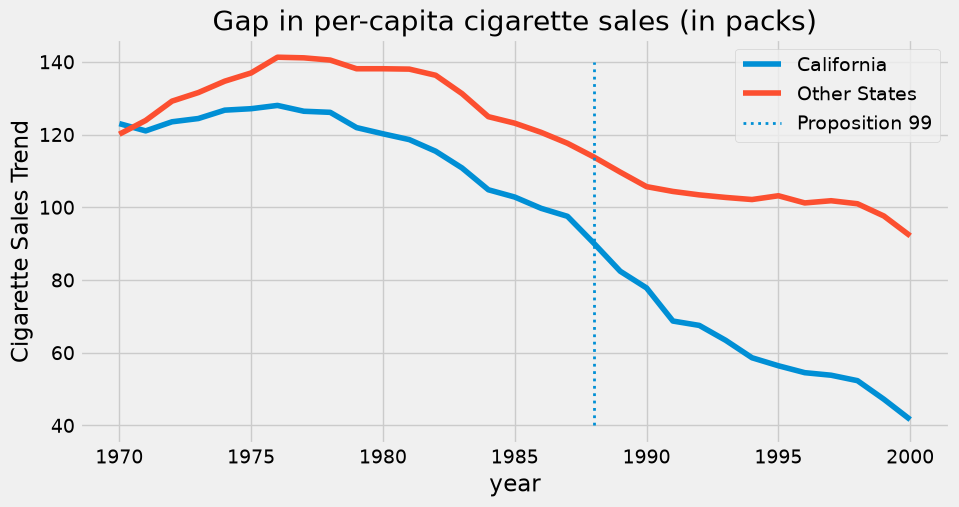

In [4]:
ax = plt.subplot(1, 1, 1)

(cigar
 .assign(california = np.where(cigar["california"], "California", "Other States"))
 .groupby(["year", "california"])
 ["cigsale"]
 .mean()
 .reset_index()
 .pivot(index="year", columns="california", values="cigsale")
 .plot(ax=ax, figsize=(10,5)))

plt.vlines(x=1988, ymin=40, ymax=140, linestyle=":", lw=2, label="Proposition 99")
plt.ylabel("Cigarette Sales Trend")
plt.title("Gap in per-capita cigarette sales (in packs)")
plt.legend();

캘리포니아 주민들은 원래부터 전국 평균보다 담배를 덜 구매하고 있었고, 1980년대 이후로 담배 소비 자체가 전반적으로 줄어드는 추세입니다. 발의안 99호 이후 캘리포니아의 감소세가 다른 주보다 더 가속화된 것처럼 보이긴 하지만, 그래프만 보고 확신할 수는 없어요. 이건 그냥 육안으로 본 추측일 뿐입니다.

이 질문에 제대로 답하려면, **개입 전 기간의 데이터**를 이용해 Synthetic Control을 구축해야 합니다. 여러 다른 주를 조합해서 **캘리포니아의 추세와 아주 비슷한 "가상의 주"**를 만들고, 이 가상의 주가 개입 후에는 어떻게 움직이는지 살펴보는 거예요.

## 1.2 시점이 훨씬 많기에 (We have Time)

### 문제를 공식적으로 정의하기

$J+1$개의 그룹이 있다고 합시다. 그중 그룹 1이 처치를 받은 대상이고, 그룹 $j=2,...,J+1$은 처치를 받지 않은 그룹들의 집합, 즉 "**donor pool**"입니다. 데이터는 개입 전 기간 $T_0$을 포함해 총 $T$ 기간에 걸쳐 있습니다.\
  - (donor pool = 가상의 대조군을 만들기 위한 재료가 되는, 처치받지 않은 그룹들의 후보 목록")

각 그룹 $j$, 각 시점 $t$에 대해 실제 관찰한 결과 $Y_{jt}$가 있고, 두 개의 잠재적 결과를 정의합니다.

- $Y^N_{jt}$: 개입이 **없었다면** 있었을 결과
- $Y^I_{jt}$: 개입이 **있었을 때**의 결과

그러면 처치를 받은 그룹 $j=1$에 대해, 개입 후 시점 $t > T_0$에서의 처치 효과는:

$$\tau_{1t} = Y^I_{1t} - Y^N_{1t}$$

그룹 1은 실제로 처치를 받았으니 $Y^I_{1t}$는 관찰할 수 있지만, $Y^N_{1t}$(처치가 없었다면?)는 관찰할 수 없는 반사실이에요. **관심의 핵심은 결국 이 $Y^N_{1t}$를 어떻게 잘 추정하는가**입니다.

한 가지 짚어둘 점: 처치 효과 $\tau_{1t}$가 시점 $t$마다 따로 정의되어 있다는 것에 주목하세요. 즉 효과는 시간에 따라 달라질 수 있습니다 — 즉시 나타날 필요도 없고, 시간이 지나며 누적되거나 줄어들 수도 있어요.

![img](data/img/synth-control/synth_img.png)

### Synthetic Control의 정의

$Y^N_{1t}$를 추정하기 위한 핵심 전제는: **donor pool에 있는 그룹들을 적절히 조합하면, 어느 한 그룹 단독보다 처치된 그룹과 훨씬 더 비슷하게 만들 수 있다**는 것입니다.

그래서 Synthetic Control은 donor pool 그룹들의 **가중 평균**으로 정의됩니다. 가중치 $\pmb{W}=(w_2,...,w_{J+1})$가 주어지면:

$$\hat{Y}^N_{1t} = \sum^{J+1}_{j=2} w_j Y_{jt}$$

수식만 보면 머리가 아플 수 있는데, 걱정 마세요. 이걸 훨씬 직관적으로 이해할 수 있는 방법이 있습니다.

### 회귀를 "거꾸로" 뒤집는다는 것의 의미

**먼저 왜 데이터 구조가 다른지부터 짚어보면**: 기존 방법(DID, 고정효과)이 다루던 데이터는 시간(연도)이 상대적으로 적고, 각 시점에 해당하는 개체(개인 등)는 많은 구조였어요.\
반대로 Synthetic Control이 마주친 상황은 **시간(연도)은 30년 가까이 되는데, 그룹(주)의 개수는 39개로 적습니다.**\
이 구조의 차이가 회귀를 "뒤집어야" 하는 이유를 만들어냅니다.

DID를 떠올려보면, 회귀분석은 기간을 나타내는 더미변수들의 **가중 평균으로 예측값을 만드는 방법**이었어요.
  * 예를 들어 회귀식이 $\hat Y = \beta_0 + \beta_1 D_{1981}$이라면, 1981년 관측치의 예측값은 $\hat Y = \beta_0 \cdot 0 + \beta_1 \cdot 1 = \beta_1$처럼 "각 더미에 계수를 곱해서 더한 값"이 되고, 이 값은 실제로 1981년 데이터들의 평균과 같습니다.
  * 여기서 더미(개인·시간 고정효과)는 우리가 알고 싶은 대상이 아니라, **걸러내야 할 잡음을 없애는 역할**이었죠. 우리가 진짜 관심있는 처치변수(예: `married`)의 계수만 결과로 얻으면 되는 구조였습니다.

즉 아래 그림처럼, **행 = 시점, 열 = 변수(더미)** 구조로 데이터를 놓고 회귀를 돌렸습니다.\
여기서 더미(개인·시간 고정효과)는 우리가 알고 싶은 대상이 아니라, **걸러내야 할 잡음을 없애는 역할**이었죠. 우리가 진짜 관심있는 처치변수(예: `married`)의 계수만 결과로 얻으면 되는 구조였습니다.

![img](data/img/synth-control/regr_time.png)

Synthetic Control 상황에서는 반대예요: **그룹(주) 수는 적고, 시점(기간) 수는 많습니다.** \
그리고 더 중요한 차이는, **이번엔 "주(state)에 대한 가중치 자체가 우리가 구하고 싶은 답"**이라는 점입니다.\
"캘리포니아를 다른 주들의 조합으로 어떻게 재현할까?"라는 질문 자체가 "각 주에 얼마의 가중치 $w$를 줄 것인가"를 묻는 것이기 때문에, 주가 더 이상 걸러낼 잡음이 아니라 회귀의 핵심 대상이 됩니다.

이 목표를 달성하려면 각 주의 실제 판매량 숫자가 회귀의 "X(설명변수)" 자리에 있어야 해요. 그래서 아이디어는 이 입력 행렬을 **뒤집는** 것입니다. 이제 **그룹(주)이 "변수"가 되고, 시점이 "관측치(행)"가 됩니다.**

![img](data/img/synth-control/regr_space.png)

**직관적으로 다시 설명하면**: 원래 DID의 회귀는 "여러 시점의 데이터를 이용해서, 더미변수(기간)의 가중치를 구하는 것"이었죠.\
Synthetic Control은 이걸 뒤집어서 "여러 시점의 데이터를 이용해서, **각 주(state)의 가중치**를 구하는 것"으로 바꿉니다.\
회귀식의 "설명변수" 자리에 다른 주들의 결과값을 넣고, 그 주들을 조합해서 캘리포니아를 최대한 잘 예측(=재현)하도록 하는 거예요.

여기서 중요한 점: **시점마다 다른 가중치를 따로 구하는 게 아닙니다.** 30개(가까운) 연도 전체를 동시에 가장 잘 만족시키는, **하나의 가중치 세트 $w_1, ..., w_{38}$**을 찾는 거예요.\
각 연도(행)는 "이 조합이면 캘리포니아가 맞아떨어지는지"를 확인해주는 하나의 증거 역할을 하고, 이렇게 구해진 가중치는 모든 연도에 공통으로 적용됩니다.

한 기간에 변수가 여러 개(예: 판매량과 가격)라면, 이 변수들을 위아래로 쌓아서 함께 사용할 수 있습니다. 서로 다른 변수에 다른 중요도를 부여하고 싶다면, 변수마다 스케일을 다르게 조정할 수도 있어요.

![img](./data/img/synth-control/regr_space_x.png)

이렇게 Synthetic Control을 "회귀"의 관점으로 볼 수 있다면, **가중치를 OLS로 추정할 수 있다**는 뜻이 됩니다. 실제로 해봅시다.

---

**정리하면:**

| | 고정효과(14장) | Synthetic Control(15장) |
|---|---|---|
| 데이터 모양 | 시간 적음, 개체 많음 | 시간 많음(30년), 개체 적음(39개 주) |
| 알고 싶은 것 | 처치변수(married)의 계수 | 각 주(state)에 부여할 가중치 |
| 더미의 역할 | 개인/시간 고정효과 **제거**용 | 사용하지 않음 — 각 주의 실제 값을 그대로 X로 사용 |
| 표 재배치 | 그대로 사용(개인×시간) | **뒤집어서** 연도×주로 재구성 |
| 회귀가 찾는 것 | "married 효과" 하나의 숫자 | 38개 주에 대한 가중치 $w_1,...,w_{38}$ (모든 연도에 공통) |

## 1-3. 선형회귀로서의 Synthetic Control

![img](./data/img/synth-control/allways.png)

Synthetic Control로 처치 효과를 추정하려면, **개입 전 기간 동안 처치된 그룹(캘리포니아)과 가장 비슷하게 움직이는 "가상의 그룹"**을 만들어야 합니다. 그런 다음 이 가상의 그룹이 개입 후에는 어떻게 움직이는지 확인하고, 실제 캘리포니아와의 차이를 처치 효과로 봅니다.

선형회귀로 이걸 구현하려면, **개입 전 기간 동안** donor pool 그룹들의 가중 평균과 처치 그룹 사이의 거리(제곱)를 최소화하는 가중치를 OLS로 찾습니다.

이를 위해 먼저 데이터의 행과 열을 바꿔야 해요: **그룹(주)을 열로, 시간을 행으로** 만듭니다. 이번 예시는 `cigsale`과 `retprice` 두 변수를 함께 쌓아서 사용할 거예요.\
- **왜 개입 전 기간만 사용하는가**: Synthetic Control은 개입 전 기간에 캘리포니아를 잘 재현하도록 만든 다음, 개입 후에 실제 캘리포니아와 얼마나 달라지는지를 보려는 것이기 때문이에요. (개입 후 데이터까지 넣으면 처치 효과 자체가 가중치 계산에 섞여 들어가버립니다.)

참고로 두 변수의 스케일이 비슷해서 이번엔 별도 조정 없이 진행하지만, 만약 한 변수는 천 단위이고 다른 변수는 소수점 단위처럼 스케일이 크게 다르면, 거리를 최소화할 때 스케일이 큰 변수가 지나치게 큰 영향력을 갖게 됩니다. 이런 경우엔 미리 스케일을 맞춰주는 게 중요해요.

In [27]:
features = ["cigsale", "retprice"]

inverted = (cigar.query("~after_treatment") # filter pre-intervention period, NOT after_treatment is TRUE (=FALSE)
            .pivot(index='state', columns="year")[features] # make one column per year and one row per state
           .T) # flip the table to have one column per state

inverted.head()

state                 1           2           3           4           5   \
        year                                                               
cigsale 1970   89.800003  100.300003  123.000000  124.800003  120.000000   
        1971   95.400002  104.099998  121.000000  125.500000  117.599998   
        1972  101.099998  103.900002  123.500000  134.300003  110.800003   
        1973  102.900002  108.000000  124.400002  137.899994  109.300003   
        1974  108.199997  109.699997  126.699997  132.800003  112.400002   

state                 6           7           8           9           10  ...  \
        year                                                              ...   
cigsale 1970  155.000000  109.900002  102.400002  124.800003  134.600006  ...   
        1971  161.100006  115.699997  108.500000  125.599998  139.300003  ...   
        1972  156.300003  117.000000  126.099998  126.599998  149.199997  ...   
        1973  154.699997  119.800003  121.800003  124.400002  156.000000  ...   
        1974  151.300003  123.699997  125.599998  131.899994  159.600006  ...   

state                 30          31          32          33         34  \
        year                                                              
cigsale 1970  103.599998   92.699997   99.800003  106.400002  65.500000   
        1971  115.000000   96.699997  106.300003  108.900002  67.699997   
        1972  118.699997  103.000000  111.500000  108.599998  71.300003   
        1973  125.500000  103.500000  109.699997  110.400002  72.699997   
        1974  129.699997  108.400002  114.800003  114.699997  75.599998   

state                 35          36          37          38          39  
        year                                                              
cigsale 1970  122.599998  124.300003  114.500000  106.400002  132.199997  
        1971  124.400002  128.399994  111.500000  105.400002  131.699997  
        1972  138.000000  137.000000  117.500000  108.800003  140.000000  
        1973  146.800003  143.100006  116.599998  109.500000  141.199997  
        1974  151.800003  149.600006  119.900002  111.800003  145.800003  

[5 rows x 39 columns]

이제 $Y$는 캘리포니아, $X$는 나머지 주들로 정의합니다.

In [36]:
y = inverted[3].values # state of california
X = inverted.drop(columns=3).values  # other states

print(y.shape, X.shape)

(38,) (38, 38)


이제 회귀를 실행합니다. 절편을 넣는 건 "모든 행이 1인 또 다른 주"를 추가하는 것과 비슷한 효과라서, 여기서는 그냥 생략할게요(넣어도 되지만 해석이 조금 더 복잡해져요). 이 회귀는 처치된 그룹과 donor pool 그룹들 사이의 제곱 차이를 최소화하는 가중치 집합을 반환합니다.

In [7]:
from sklearn.linear_model import LinearRegression
weights_lr = LinearRegression(fit_intercept=False).fit(X, y).coef_
weights_lr.round(3)

array([-0.436, -1.038,  0.679,  0.078,  0.339,  1.213,  0.143,  0.555,
       -0.295,  0.052, -0.529,  1.235, -0.549,  0.437, -0.023, -0.266,
       -0.25 , -0.667, -0.106, -0.145,  0.109,  0.242, -0.328,  0.594,
        0.243, -0.171, -0.02 ,  0.14 , -0.811,  0.362,  0.519, -0.304,
        0.805, -0.318, -1.246,  0.773, -0.055, -0.032])

이 가중치가 바로 Synthetic Control을 만드는 방법을 알려줍니다. 예를 들어 주 1의 결과에 -0.436, 주 2의 결과에 -1.038, 주 4의 결과에 0.679를 곱하는 식이에요. donor pool 주들의 결과 행렬과 이 가중치를 곱해서 Synthetic Control을 계산합니다.

In [37]:
calif_synth_lr = (cigar.query("~california")
                  .pivot(index='year', columns="state")["cigsale"]
                  .values.dot(weights_lr))

이제 Synthetic Control과 캘리포니아의 실제 결과를 나란히 그려볼게요.

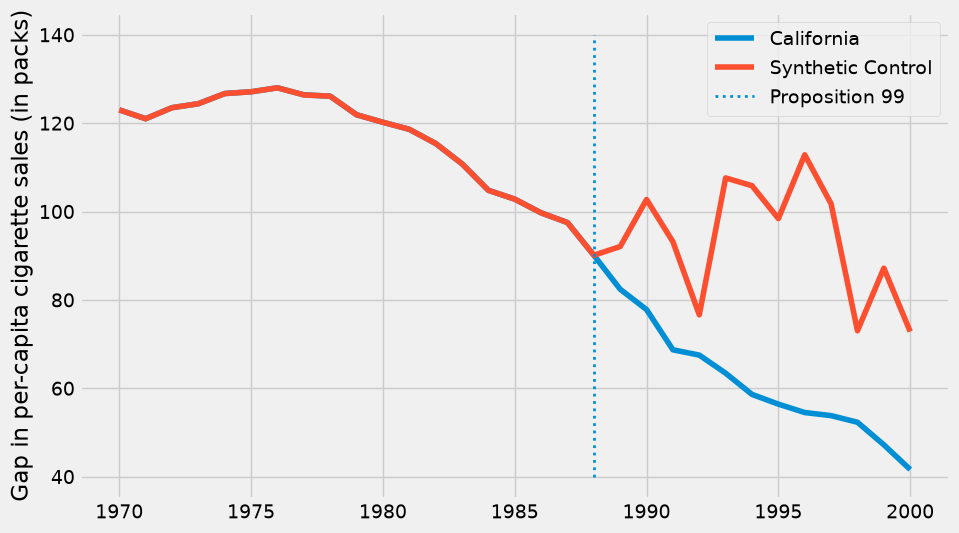

In [9]:
plt.figure(figsize=(10,6))
plt.plot(cigar.query("california")["year"], cigar.query("california")["cigsale"], label="California")
plt.plot(cigar.query("california")["year"], calif_synth_lr, label="Synthetic Control")
plt.vlines(x=1988, ymin=40, ymax=140, linestyle=":", lw=2, label="Proposition 99")
plt.ylabel("Gap in per-capita cigarette sales (in packs)")
plt.legend();

### 뭔가 이상한 결과 — 왜 그럴까

그래프를 보면 이상한 점 두 가지가 보여요.

1. **개입 전 기간이 너무 완벽하게 일치한다**: Synthetic Control이 캘리포니아를 거의 정확히 재현하고 있어요.
2. **개입 후 Synthetic Control의 값이 위아래로 심하게 흔들린다**: 매끄러운 추세를 따르지 않고 들쭉날쭉해요.

![img](./data/img/synth-control/out-of-sample.png)

**이게 왜 문제인가**: 개입 전 기간을 "완벽히" 맞춘다는 건 좋은 신호가 아니라, 오히려 **과적합(overfitting)**의 신호입니다.
  - donor pool에는 38개 주가 있고, 이 회귀는 그 38개 주 각각에 가중치를 부여할 수 있어요.
  - 즉 **38개의 자유로운 매개변수**로, 캘리포니아의 개입 전 데이터(기간 수만큼의 관측치)를 맞추는 셈입니다.
  - 관측치 수(기간)가 매개변수 수(주 개수)와 비슷하거나 그보다 적으면, 모델은 실제 패턴을 학습하는 대신 **노이즈까지 억지로 끼워 맞추게** 됩니다.

이건 마치 점 10개를 지나가는 곡선을 그릴 때, 자유도가 충분히 높으면 그 10개 점을 다 통과하는 구불구불한 선을 그릴 수 있는 것과 비슷해요.\
이 선은 훈련 데이터(개입 전)는 완벽하게 맞추지만, 새로운 데이터(개입 후)에서는 형편없이 튀는 겁니다.\
Ridge나 Lasso 같은 정규화(regularization) 기법으로 이 문제를 풀 수도 있지만, 여기서는 Synthetic Control 특유의 전통적인 해법을 살펴봅니다.

## 1-4. 외삽하지 말 것 (Don't Extrapolate)

아래처럼 데이터가 있고, 대조군들의 선형결합으로 처치 그룹을 재현하는 Synthetic Control을 만들어야 한다고 해봅시다.

|unit|sales|price|
|--|--|--|
|control 1|8|8|
|control 2|8|4|
|control 3|4|5|
|treated  |2|10|

집단은 3개, 속성은 2개뿐이라 정확히 일치시키는 조합이 여러 개 있을 수 있어요. 그 중 하나는 control 1에 2.25를, control 2에 -2를 곱해서 더하는 방법입니다.

**여기서 문제가 되는 부분**: control 2에 **음수(-2)**를 곱하면 판매량 -16, 가격 -8이라는, 현실에 존재할 수 없는 값이 만들어져요.\
음수인 판매량이나 가격은 있을 수 없는데, 이 가중치는 그런 말도 안 되는 영역까지 이 그룹을 "확장(추정)"하고 있는 거예요.\
control 1에 2.25를 곱한 것도 마찬가지로, 판매량과 가격을 18이라는 데이터에 없는 극단적으로 높은 값까지 밀어붙입니다.
> 데이터에 존재하는 범위를 벗어나 값을 추정하는 것을 **외삽(extrapolation)**이라고 해요.

이게 바로 회귀에 Synthetic Control을 맡기면 실제로 벌어지는 일입니다. 외삽 자체가 수학적으로 잘못된 건 아니지만, 실전에서는 위험해요. **한 번도 본 적 없는 영역의 데이터가, 우리가 가진 데이터와 똑같이 행동할 것**이라고 가정하는 셈이니까요.

### 해법: 보간(interpolation)만 허용하기

더 안전한 방법은, Synthetic Control이 **보간(interpolation)만** 하도록 제한하는 것입니다. 방법은 간단해요: **가중치를 양수로만 제한**하고, **가중치의 합이 1이 되도록** 강제하는 것.

이렇게 하면 Synthetic Control은 donor pool 그룹들의 **convex combination**(모든 가중치가 0 이상이고 합이 1인 조합)이 됩니다. 이 경우, 처치 그룹은 대조군들이 만들어내는 **convex hull**(대조군들을 감싸는 다각형 영역) 내부로 투영됩니다.

![img](data/img/synth-control/extrapolation.png)

주목할 점 두 가지가 있습니다.

1. **완벽하게 일치하지 않을 수 있음**: 처치 그룹(가장 낮은 판매량, 가장 높은 가격)이 대조군들의 영역 바깥에 있다면, convex combination으로는 그 지점을 정확히 복제할 수 없어요. Convex combination은 오직 대조군들 **사이**에 있는 값만 정확히 재현할 수 있습니다.
2. **가중치가 희소(sparse)함**: 보간은 convex hull의 "벽"에 처치 그룹을 투영하는 방식이고, 이 벽은 소수의 그룹만으로 정의됩니다. 그래서 많은 그룹이 가중치 0을 받게 됩니다 (아까 확인했던 "38개의 자유로운 매개변수" 문제가, 이 제약 덕분에 실제로는 소수의 그룹에만 무게가 실리게 되면서 자연스럽게 줄어드는 거예요).

### 제약을 반영한 새로운 최적화 식

Synthetic Control의 정의는 여전히 같습니다.

$$\hat{Y}^N_{jt} = \sum^{J+1}_{j=2} w_j Y_{jt}$$

다만 이제는 아래 식을 최소화하는 가중치 $\pmb{W}=(w_2,...,w_{J+1})$를 찾습니다.

$$||\pmb{X}_1 - \pmb{X}_0 \pmb{W}|| = \bigg(\sum^k_{h=1}v_h \bigg(X_{h1} - \sum^{J+1}_{j=2} w_j X_{hj} \bigg)^2 \bigg)^{\frac{1}{2}}$$

**이 식이 왜 이렇게 생겼는지 하나씩 풀어보면**:
  - $X_{h1} - \sum w_j X_{hj}$: 캘리포니아의 $h$번째 변수 값에서 Synthetic Control의 $h$번째 변수 값을 뺀 것 — 한 변수에서의 오차입니다. (기존과 동일)
  - 제곱 $(\cdot)^2$: 오차의 부호를 없애고 크기만 남깁니다. OLS에서 오차를 제곱하던 것과 같은 논리예요.
  - 바깥쪽 $\sum^k_{h=1}$: 변수가 여러 개(판매량, 가격 등 $k$개)이므로, 각 변수에서 생긴 오차를 모두 더해 하나의 전체 오차로 합칩니다.
  - 맨 바깥의 $(\cdot)^{1/2}$: 제곱해서 더한 것에 루트를 씌우는 건, 이 식 자체가 유클리드 거리(벡터 간 거리) 공식이기 때문입니다. 즉 이 손실함수는 "캘리포니아 벡터"와 "가중치로 합성한 벡터" 사이의 거리를 재는 것과 같습니다.

이때 $w_2,...,w_{J+1}$은 **모두 양수이고 합이 1**이라는 제약을 받습니다. 이 제약은 수식 자체에는 보이지 않지만, 손실함수를 최소화할 때 반드시 지켜야 하는 별도의 규칙이에요.\
(앞서 일반 `LinearRegression`으로 가중치를 구했을 때는 이 제약이 없어서 음수 가중치, 즉 외삽이 나왔었죠.)

여기서 $v_h$는 각 변수(feature) $h$에 부여하는 중요도예요 — 처치 그룹과 Synthetic Control의 차이를 최소화할 때, 어떤 변수를 더 중요하게 볼지를 반영합니다. 
- 판매량과 가격처럼 변수의 스케일이 다르면, 그냥 더할 경우 스케일이 큰 변수의 오차가 전체 거리를 지배해버릴 수 있어서, $v_h$로 이를 조정해줄 수 있습니다.

$v$를 정하는 방법은 여러 가지가 있어요. 가장 단순한 방법은 각 변수를 평균 0, 분산 1로 표준화하는 것이고, 더 정교한 방법은 $Y$를 예측하는 데 더 도움이 되는 변수에 더 큰 중요도를 자동으로 부여하는 것입니다.\
여기서는 코드를 단순하게 유지하기 위해 모든 변수에 동일한 중요도($v_h=1$)를 부여할게요.

**즉 이전에 봤던 단순한 오차제곱합 손실함수와 비교하면, 이번 식에서 새로 추가된 요소는 두 가지입니다**: 
  - ① 변수별 중요도 $v_h$ (다만 여기서는 전부 1로 통일해서 실질적으로는 안 쓰임)
  - ② 가중치에 대한 제약(양수, 합=1). 오차를 제곱해서 합친다는 기본 골격 자체는 동일합니다.

이를 구현하기 위해, 먼저 위 손실함수를 코드로 정의합니다.

In [11]:
from typing import List
from operator import add
from toolz import reduce, partial

def loss_w(W, X, y) -> float:
    return np.sqrt(np.mean((y - X.dot(W))**2))

모든 변수에 동일한 중요도를 주기로 했으니 $v$는 따로 신경 쓰지 않아도 됩니다.

이제 최적의 가중치를 구하기 위해 `scipy`의 2차 계획법(quadratic programming) 최적화를 사용할게요. 우리가 회귀 대신 이 방법을 쓰는 이유는, **가중치가 양수이고 합이 1**이라는 제약 조건을 그냥 OLS로는 걸 수 없기 때문입니다. 이 제약을 명시적으로 넣어줄 수 있는 최적화 함수가 필요해요.

```python
lambda x: np.sum(x) - 1
```

이 조건으로 "가중치의 합이 1"이 되도록 강제하고, 각 가중치의 범위를 0과 1 사이로 제한합니다.

In [12]:
from scipy.optimize import fmin_slsqp
# fmin_slsqp(Sequential Least Squares Programming)는 반복적으로 값을 조금씩 개선해나가는 최적화 알고리즘

def get_w(X, y):
    
    w_start = [1/X.shape[1]]*X.shape[1] #각 주에 똑같이 1/38의 가중치로 시작하기 위해서

    weights = fmin_slsqp(partial(loss_w, X=X, y=y), # 최소화할 손실함수
                         np.array(w_start), # 시작점
                         f_eqcons=lambda x: np.sum(x) - 1, # 등식 제약: 합 = 1
                         bounds=[(0.0, 1.0)]*len(w_start), # 각 가중치는 0~1 사이

                         disp=False)
    return weights

이를 실행하면 Synthetic Control을 정의하는 가중치를 얻습니다.

In [13]:
calif_weights = get_w(X, y)
print("Sum:", calif_weights.sum())
np.round(calif_weights, 4)

Sum: 1.0000000000001636


array([0.    , 0.    , 0.    , 0.0852, 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.113 , 0.1051, 0.4566, 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.2401, 0.    , 0.    , 0.    , 0.    , 0.    ])

이 가중치를 보면 주 1, 2, 3에는 0을, 주 4에는 0.0852를 부여하고 있어요. 예상했던 대로 가중치가 **희소(sparse)**하다는 걸 확인할 수 있고, 모든 가중치의 합이 1이면서 0과 1 사이에 있어 convex combination 제약도 만족합니다.

이 가중치를 앞서와 똑같은 방식으로 각 주의 결과값에 곱해서 Synthetic Control을 만들 수 있어요.

In [40]:
calif_synth = cigar.query("~california").pivot(index='year', columns="state")["cigsale"].values.dot(calif_weights)
calif_synth

array([116.37738088, 119.29341338, 125.46488163, 124.01126515,
       125.00610864, 126.12812191, 128.40416473, 126.3335483 ,
       125.65842479, 122.57699531, 121.02481026, 120.79008431,
       115.81667702, 112.72157965, 104.13403043, 103.31383472,
       101.6782838 , 100.3114036 ,  92.60414378,  89.97954325,
        84.4743554 ,  80.41630978,  80.45152512,  79.60028843,
        79.11292838,  77.89062048,  77.22867228,  77.49826228,
        75.00565126,  73.83549182,  66.43015825])

이제 Synthetic Control을 그려보면 훨씬 부드러운 추세를 확인할 수 있습니다. 개입 전 기간에도 더 이상 완벽하게 일치하지는 않는데, 이건 오히려 좋은 신호예요 — 우리가 더 이상 과적합되지 않았다는 뜻입니다.

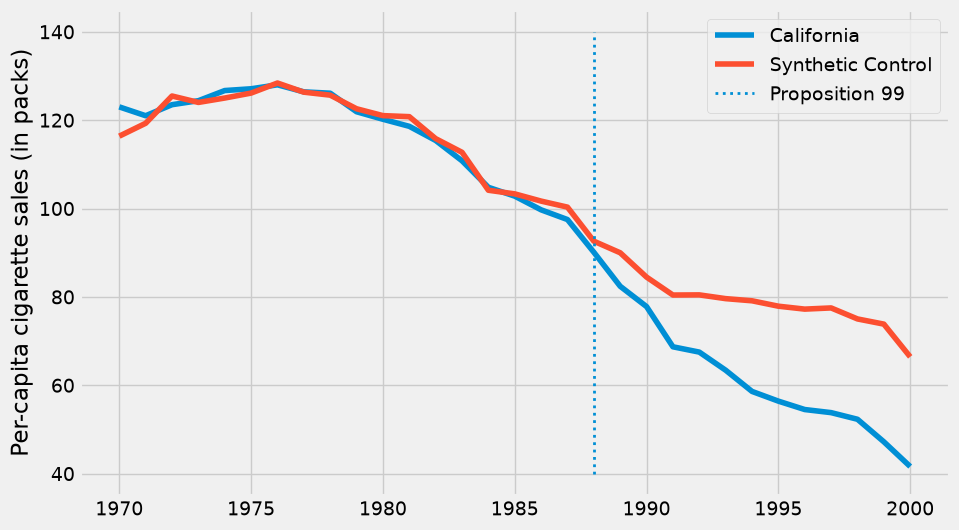

In [15]:
plt.figure(figsize=(10,6))
plt.plot(cigar.query("california")["year"], cigar.query("california")["cigsale"], label="California")
plt.plot(cigar.query("california")["year"], calif_synth, label="Synthetic Control")
plt.vlines(x=1988, ymin=40, ymax=140, linestyle=":", lw=2, label="Proposition 99")
plt.ylabel("Per-capita cigarette sales (in packs)")
plt.legend();

이제 처치 효과는 실제 캘리포니아의 결과와 Synthetic Control의 차이로 추정할 수 있습니다.

$$\tau_{1t} = Y^I_{1t} - Y^N_{1t}$$

이 사례에서는 시간이 지날수록 그 효과가 점점 커지는 것으로 보입니다.

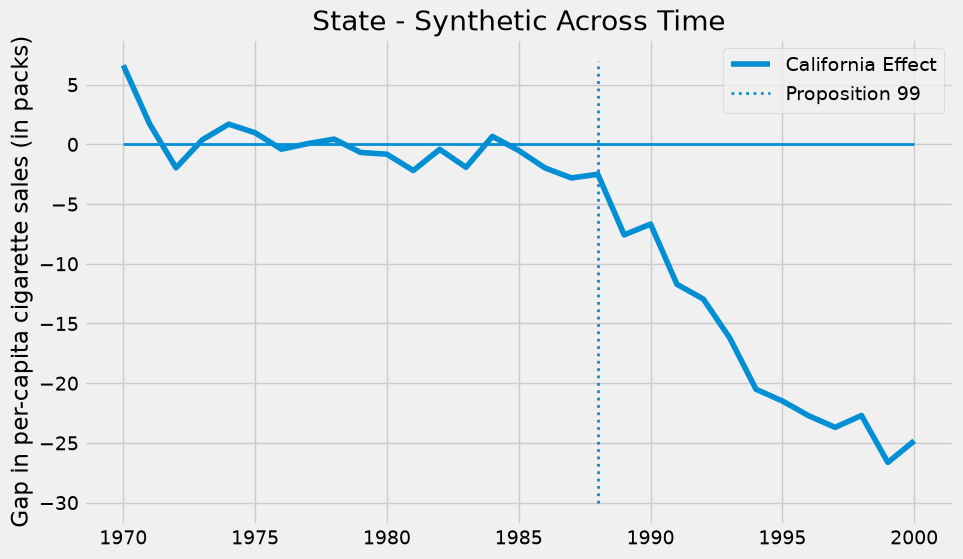

In [16]:
plt.figure(figsize=(10,6))
plt.plot(cigar.query("california")["year"], cigar.query("california")["cigsale"] - calif_synth,
         label="California Effect")
plt.vlines(x=1988, ymin=-30, ymax=7, linestyle=":", lw=2, label="Proposition 99")
plt.hlines(y=0, xmin=1970, xmax=2000, lw=2)
plt.title("State - Synthetic Across Time")
plt.ylabel("Gap in per-capita cigarette sales (in packs)")
plt.legend();

2000년까지 발의안 99호가 담배 판매량을 약 25갑이나 줄인 것처럼 보입니다. 인상적인 결과지만, 스스로 물어봐야 할 질문이 남아있어요: **이게 통계적으로 유의미한지 어떻게 알 수 있을까요?**

## 추론하기 (Making Inference)

### Fisher's Exact Test의 아이디어

표본 크기가 39개(주 39개)로 매우 작기 때문에, 이 결과가 단순히 무작위적인 운이 아니라 통계적으로 유의미한지 판단할 때 좀 더 신중한 방법이 필요합니다. 여기서는 **Fisher's Exact Test**의 아이디어를 빌려옵니다.

직관은 아주 간단해요: **"처치를 받았다"는 라벨을 다른 주들에도 돌려가며 붙여봅니다.** 처치를 받은 그룹은 원래 캘리포니아 하나뿐이지만, 이번엔 다른 모든 주도 한 번씩 "처치받은 주인 척" 가정하고 나머지 주들로 그 주의 Synthetic Control을 만들어봅니다.

|iteration|1|2|...|39|
|----|-|-|-|-|
|1|treated|0|0|0|
|2|0|treated|0|0|
|...|0|0|0|0|0|0|
|39|0|0|0|treated|

이렇게 하면 39개의 Synthetic Control과 39개의 "효과 추정치"를 얻게 됩니다. 이 중 38개는 **실제로는 처치가 일어나지 않았는데도** 계산된 가짜 효과, 즉 **플라시보 효과(placebo effect)**예요.

**논리는 이렇습니다**: 만약 캘리포니아의 효과가 이 38개의 플라시보 효과들보다 훨씬 크고 극단적이라면, 캘리포니아의 결과는 단순한 우연이나 잡음이 아니라 실제 처치 효과일 가능성이 높다고 볼 수 있습니다.\
반대로 다른 주들에도 비슷한 크기의 "효과"가 흔하게 나타난다면, 캘리포니아에서 본 결과도 그냥 우연일 수 있다는 뜻이겠죠.

### 모든 주에 대해 Synthetic Control 계산하기

이를 구현하기 위해, 어떤 주를 입력받으면 그 주에 대한 Synthetic Control을 계산해주는 함수를 만듭니다. 이 함수는 주, 연도, 실제 담배 판매량(`cigsale`), 그리고 그 주에 대한 Synthetic Control 결과를 담은 데이터프레임을 반환합니다.

In [41]:
def synthetic_control(state: int, data: pd.DataFrame) -> np.array:
    
    features = ["cigsale", "retprice"]
    
    inverted = (data.query("~after_treatment")
                .pivot(index='state', columns="year")[features]
                .T)
    
    y = inverted[state].values # treated state를  
    X = inverted.drop(columns=state).values # donor pool
    # inverted의 컬럼 이름 자체가 "1", "2", "3" 같은 주 번호

    weights = get_w(X, y)
    synthetic = (data.query(f"~(state=={state})")
                 .pivot(index='year', columns="state")["cigsale"]
                 .values.dot(weights))

    return (data
            .query(f"state=={state}")[["state", "year", "cigsale", "after_treatment"]]
            .assign(synthetic=synthetic))

첫 번째 주에 적용한 결과는 다음과 같습니다.

In [18]:
synthetic_control(1, cigar).head()

,state,year,cigsale,after_treatment,synthetic
0,1,1970,89.800003,False,95.029419
1,1,1971,95.400002,False,99.118199
2,1,1972,101.099998,False,101.881329
3,1,1973,102.900002,False,103.938655
4,1,1974,108.199997,False,107.038474


모든 주에 대해 이 계산을 반복해야 하므로, 8개 프로세스로 병렬 처리해서 속도를 높입니다. 컴퓨터의 코어 수에 맞게 숫자를 조정하시면 됩니다.

In [43]:
from joblib import Parallel, delayed

control_pool = cigar["state"].unique() # 1~39

parallel_fn = delayed(partial(synthetic_control, data=cigar))

synthetic_states = Parallel(n_jobs=8)(parallel_fn(state) for state in control_pool)

#Parallel, delayed 사용법 관련해서는 아래쪽에 정리해둠

In [44]:
synthetic_states[0].head()

,state,year,cigsale,after_treatment,synthetic
0,1,1970,89.800003,False,95.029419
1,1,1971,95.400002,False,99.118199
2,1,1972,101.099998,False,101.881329
3,1,1973,102.900002,False,103.938655
4,1,1974,108.199997,False,107.038474


모든 주에 대한 Synthetic Control이 준비되었으니, 각 주의 실제 결과와 Synthetic Control 사이의 차이(gap)를 계산할 수 있습니다. 캘리포니아의 경우 이 차이가 곧 처치 효과이고, 나머지 주들의 경우는 (실제로는 처치가 없었으니) 플라시보 효과입니다. 캘리포니아의 효과와 모든 플라시보 효과를 함께 그려볼게요.

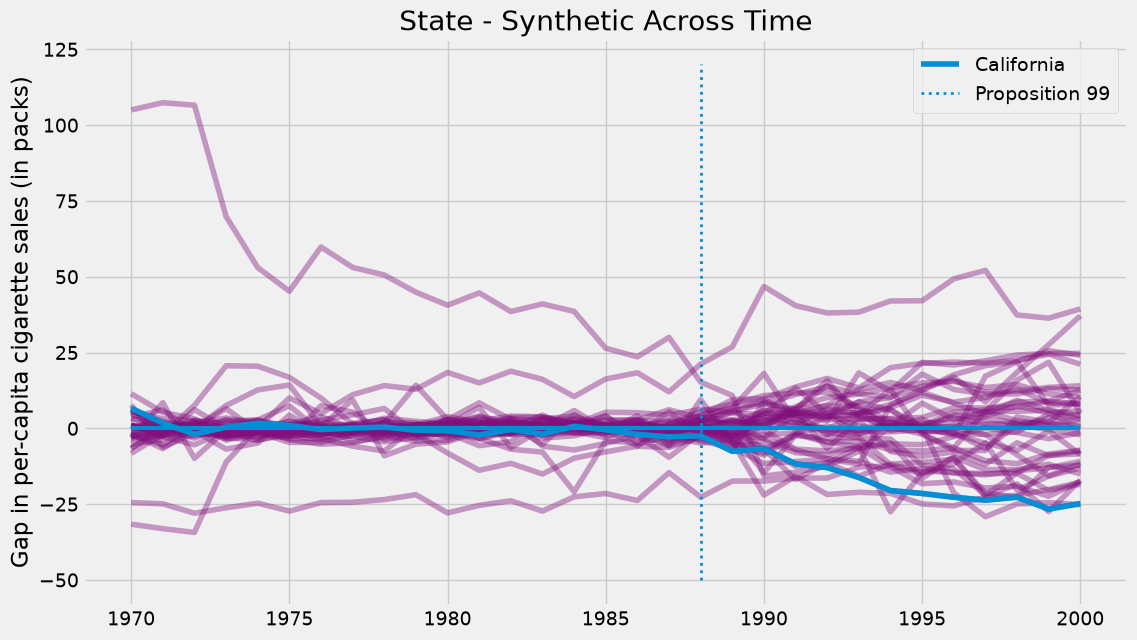

In [21]:
plt.figure(figsize=(12,7))
for state in synthetic_states:
    plt.plot(state["year"], state["cigsale"] - state["synthetic"], color="C5",alpha=0.4)

plt.plot(cigar.query("california")["year"], cigar.query("california")["cigsale"] - calif_synth,
        label="California");

plt.vlines(x=1988, ymin=-50, ymax=120, linestyle=":", lw=2, label="Proposition 99")
plt.hlines(y=0, xmin=1970, xmax=2000, lw=3)
plt.ylabel("Gap in per-capita cigarette sales (in packs)")
plt.title("State - Synthetic Across Time")
plt.legend();

### 결과에서 눈여겨볼 두 가지

1. **개입 후 분산이 개입 전보다 크다**: Synthetic Control은 애초에 개입 **전** 기간의 차이를 최소화하도록 설계되어 있으니, 개입 후에는 그 "맞춰짐"이 사라지면서 흩어지는 게 당연합니다.
2. **개입 전에도 잘 맞지 않는 주들이 있다**: 예를 들어 어떤 주가 원래부터 담배 소비량이 극단적으로 높거나 낮다면, 다른 주들의 convex combination으로는 절대 그 주를 잘 재현할 수 없습니다.

이렇게 원래부터 잘 맞지 않는 주는 분석에서 걸러내는 게 좋습니다. 객관적인 기준으로는 **개입 전 기간의 오차(MSE)**에 임계값을 두는 방법이 있어요.

$$MSE = \frac{1}{N}\sum\bigg(Y_t - \hat{Y}^{Synth}_t\bigg)^2$$

오차가 높은 주들을 제거하고 다시 그려보면 다음과 같습니다.

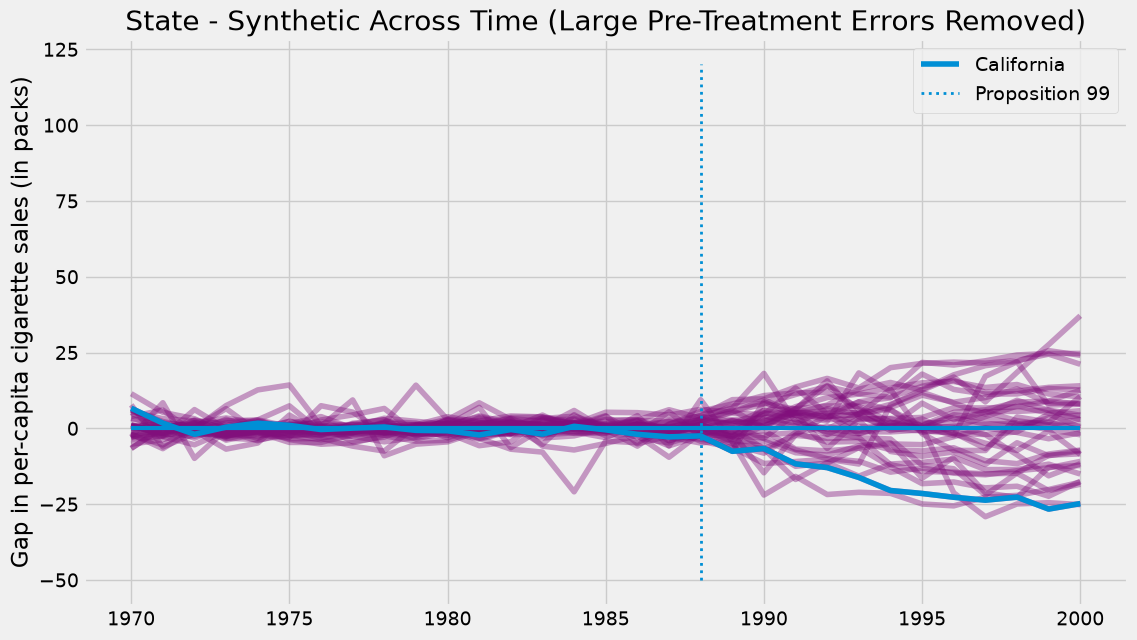

In [22]:
def pre_treatment_error(state):
    pre_treat_error = (state.query("~after_treatment")["cigsale"] 
                       - state.query("~after_treatment")["synthetic"]) ** 2
    return pre_treat_error.mean()

plt.figure(figsize=(12,7))
for state in synthetic_states:
    
    # remove units with mean error above 80.
    if pre_treatment_error(state) < 80:
        plt.plot(state["year"], state["cigsale"] - state["synthetic"], color="C5",alpha=0.4)

plt.plot(cigar.query("california")["year"], cigar.query("california")["cigsale"] - calif_synth,
        label="California");

plt.vlines(x=1988, ymin=-50, ymax=120, linestyle=":", lw=2, label="Proposition 99")
plt.hlines(y=0, xmin=1970, xmax=2000, lw=3)
plt.ylabel("Gap in per-capita cigarette sales (in packs)")
plt.title("Distribution of Effects")
plt.title("State - Synthetic Across Time (Large Pre-Treatment Errors Removed)")
plt.legend();

잡음이 되는 주들을 제거하고 보니, 캘리포니아에서 나타난 효과가 얼마나 극단적인지가 훨씬 뚜렷하게 드러납니다. 이 그림은, 만약 처치가 다른 어떤 주에서 일어났다고 가정해도, 캘리포니아에서 본 것만큼 극단적인 효과를 얻기는 어렵다는 걸 보여줍니다.

### P-value로 구체화하기

이 그림 자체로도 하나의 추론 방식이지만, 여기서 P-value를 계산해서 더 구체적인 수치로 나타낼 수도 있습니다. 방법은: **캘리포니아의 효과가 다른 (플라시보) 효과들보다 얼마나 더 극단적인지**를 비율로 확인하는 것입니다.

In [23]:
calif_number = 3

effects = [state.query("year==2000").iloc[0]["cigsale"] - state.query("year==2000").iloc[0]["synthetic"]
           for state in synthetic_states
           if pre_treatment_error(state) < 80] # filter out noise

calif_effect = cigar.query("california & year==2000").iloc[0]["cigsale"] - calif_synth[-1] 

print("California Treatment Effect for the Year 2000:", calif_effect)
np.array(effects)

California Treatment Effect for the Year 2000: -24.830159772878012


array([  5.79715885,   0.89458999, -24.83015973,  -7.16628122,
       -10.92204863,  37.11640557, -15.06971718,  -0.4980514 ,
       -18.45795059,  21.13366449,  12.5778278 ,  -1.47547827,
        10.49627401, -11.67012348,   4.29850811,   8.04811406,
        14.02322407,   8.25002731,   0.32576356,  -8.40826859,
        -2.12402705,  -7.42865028,   2.96157523,  24.1047814 ,
         4.25211767, -17.75844565,   7.93334015,   2.81640126,
        12.64955968, -17.47677513, -25.16040939, -12.26469139,
        24.69067353,  10.3629957 ,  -8.59880355])

캘리포니아의 효과가 0보다 작다는 단측 가설을 검정하려면, 캘리포니아의 효과가 다른 모든 (플라시보) 효과보다 더 낮은 비율을 P-value로 추정할 수 있습니다.

$$PV=\frac{1}{N}\sum \mathcal{1}\{\hat{\tau}_{Calif} > \hat{\tau}_j\}$$

계산해보면, 2000년 캘리포니아의 처치 효과는 -24.8로, 개입으로 담배 소비가 거의 25갑 줄어든 것으로 나타납니다. 우리가 추정한 34개의 다른 플라시보 효과 중 딱 1개만 캘리포니아의 효과보다 더 큰(더 음수인) 값을 보였어요. 따라서 P-value는 1/35입니다.

In [24]:
np.mean(np.array(effects) < calif_effect)

np.float64(0.02857142857142857)

마지막으로, 캘리포니아의 효과가 실제로 얼마나 극단적인지를 히스토그램으로 시각화해볼 수 있습니다.

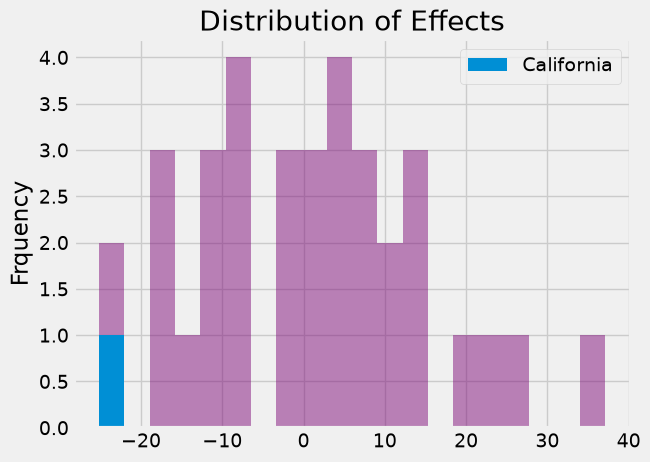

In [25]:
_, bins, _ = plt.hist(effects, bins=20, color="C5", alpha=0.5);
plt.hist([calif_effect], bins=bins, color="C0", label="California")
plt.ylabel("Frquency")
plt.title("Distribution of Effects")
plt.legend();

## 핵심 정리 (Key Ideas)

- 도시나 주처럼 **집계된 수준의 데이터만** 있으면, DID로는 신뢰할 수 있는 추론(표준오차 계산)을 하기 어렵습니다. 또한 단일 대조군을 정해야 하는데, 그 대조군이 처치 그룹의 counterfactual로 적합하지 않을 수 있다는 한계도 있습니다.
- **Synthetic Control**은 여러 대조군을 조합해서 처치 그룹과 매우 유사한 "가상의 그룹"을 만들어, 처치가 없었다면 어떤 일이 있었을지를 추정하게 해줍니다.
- 이때 **가중치를 양수로, 합을 1로 제한**해서 convex combination만 허용하는 것이 중요합니다. 이렇게 하면 과적합과 무리한 외삽을 방지할 수 있습니다.
- **Fisher's Exact Test**(플라시보 테스트)를 이용해 Synthetic Control의 결과가 통계적으로 유의미한지 판단할 수 있습니다. 처치받지 않은 그룹들도 처치받은 것처럼 가정해서 계산한 "플라시보 효과"들과 실제 효과를 비교하는 방식입니다.

## 참고 자료

이 책을 쓰기 위해 Joshua Angrist, Alberto Abadie, Christopher Walters의 대단한 계량 경제학 수업 자료를 많이 참고했습니다. 해당 자료에 있는 대부분의 아이디어는 전미경제학회(American Economic Association)의 수업에서 가져왔어요.

* [Cross-Section Econometrics](https://www.aeaweb.org/conference/cont-ed/2017-webcasts)
* [Mastering Mostly Harmless Econometrics](https://www.aeaweb.org/conference/cont-ed/2020-webcasts)

또한, Angrist의 좋은 책들도 참고자료로 추천합니다.

* [Mostly Harmless Econometrics](https://www.mostlyharmlesseconometrics.com/)
* [Mastering 'Metrics](https://www.masteringmetrics.com/)

Miguel Hernan과 Jamie Robins의 책도 큰 도움이 되었습니다.

* [Causal Inference Book](https://www.hsph.harvard.edu/miguel-hernan/causal-inference-book/)

Scott Cunningham의 Mixtape 자료에도 감사를 전합니다.

* [Causal Inference: The Mixtape](https://www.scunning.com/mixtape.html)

![img](./data/img/poetry.png)

## 기여하기 (Contribute)

Causal Inference for the Brave and True는 인과추론·통계학에 대한 오픈소스 자료입니다. 금전적으로 지원하고 싶으시다면 [Patreon](https://www.patreon.com/causal_inference_for_the_brave_and_true)을 방문해주세요. 오타 수정이나 피드백은 [Github 이슈 페이지](https://github.com/CausalInferenceLab/Causal-Inference-with-Python/issues)에서 남길 수 있습니다. 도움이 되셨다면 [한국어 번역 자료](https://github.com/CausalInferenceLab/Causal-Inference-with-Python/stargazers)와 [원서 저장소](https://github.com/matheusfacure/python-causality-handbook/stargazers)에 star를 부탁드립니다!

### joblib으로 함수를 병렬 처리하는 방법

`mydef(x, y)`라는 함수를 여러 입력값에 대해 병렬로 돌리고 싶다면, 아래 순서로 코드를 짭니다.

**1. 처리할 입력값 목록 만들기**

x가 0~19, y가 0~19인 모든 조합을 만들고 싶다면:

```python
control_pool = [(i, j) for i in range(20) for j in range(20)]
```

이렇게 하면 `(0,0), (0,1), ..., (19,19)` 형태의 튜플 400개가 담긴 리스트가 만들어집니다.

**2. `delayed`로 함수 감싸기**

`delayed`는 함수를 "즉시 실행"이 아니라 "나중에 병렬로 실행할 작업"으로 예약해주는 래퍼입니다.

```python
from joblib import Parallel, delayed

parallel_fn = delayed(mydef)
```

**주의**: `partial`은 인자 중 일부를 **미리 고정**할 때만 필요합니다. `mydef(x, y)`처럼 매번 x, y 둘 다 다른 값을 넣고 싶은 경우엔 고정할 인자가 없으니 `partial`이 필요 없고, 그냥 함수를 `delayed`로 감싸면 됩니다.

**3. `Parallel`로 실행하기**

```python
result = Parallel(n_jobs=8)(parallel_fn(x, y) for x, y in control_pool)
```

`for x, y in control_pool`처럼 튜플을 `x, y`로 풀어서(unpack) `mydef(x, y)` 형태로 호출합니다. `n_jobs=8`은 최대 8개까지 동시에(병렬로) 처리하라는 뜻입니다.

**전체 코드**

```python
from joblib import Parallel, delayed

# (x, y) 조합 400개 만들기
control_pool = [(i, j) for i in range(20) for j in range(20)]

# mydef는 고정할 인자가 없으니 partial 없이 바로 delayed로 감싸기
parallel_fn = delayed(mydef)

# 각 (x, y) 튜플을 풀어서 mydef(x, y) 형태로 호출
result = Parallel(n_jobs=8)(parallel_fn(x, y) for x, y in control_pool)
```

**만약 인자 중 하나를 고정하고 싶다면 (참고)**

예를 들어 `y`는 항상 100으로 고정하고 `x`만 바꾸고 싶다면, 이때는 `partial`이 필요합니다.

```python
control_pool = list(range(20))  # x만 0~19

parallel_fn = delayed(partial(mydef, y=100))  # y=100 고정

result = Parallel(n_jobs=8)(parallel_fn(x) for x in control_pool)
```

이 패턴은 원본 노트북의 `synthetic_control` 예시에서 `data=cigar`를 고정했던 것과 정확히 같은 구조입니다.

```python
parallel_fn = delayed(partial(synthetic_control, data=cigar))
synthetic_states = Parallel(n_jobs=8)(parallel_fn(state) for state in control_pool)
```

**정리**

| | 고정 인자 없음 | 고정 인자 있음 |
|---|---|---|
| 함수 감싸기 | `delayed(mydef)` | `delayed(partial(mydef, y=100))` |
| 호출 방식 | `parallel_fn(x, y)` | `parallel_fn(x)` |